In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

In [2]:
df = pd.read_csv("/kaggle/input/datasets/lokeshhate/zomato-dataset/Dataset .csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

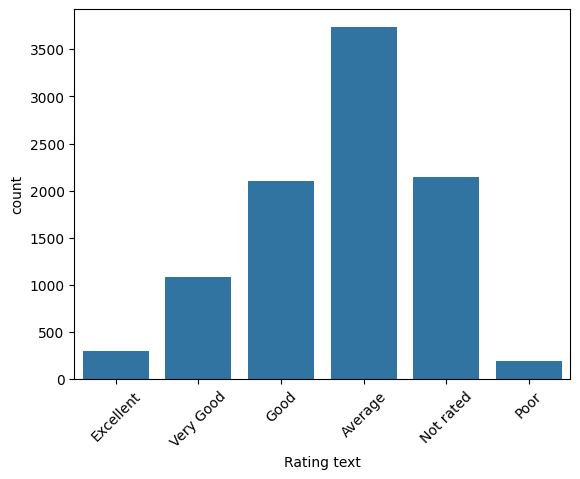

In [3]:
#EDa
df.shape
df.info()
df.isnull().sum()

sns.countplot(x="Rating text", data=df)
plt.xticks(rotation=45)
plt.show()

In [22]:
#Data Cleaning
drop_cols = [
    "Restaurant ID",
    "Restaurant Name",
    "Address",
    "Locality",
    "Locality Verbose",
    "Rating color"   # Remove because it leaks target information
]

df.drop(columns=drop_cols, inplace=True)


In [24]:
df["Cuisines"] = df["Cuisines"].fillna("Unknown")

df["Currency"] = df["Currency"].fillna(df["Currency"].mode()[0])

In [25]:
df["Cuisine Count"] = df["Cuisines"].apply(
    lambda x: len(str(x).split(","))
)

In [26]:
X = df.drop("Rating text", axis=1)
y = df["Rating text"]

In [27]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

In [33]:
X.columns = X.columns.str.replace(" ", "_")

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [30]:
#Encode Features
from sklearn.preprocessing import LabelEncoder

categorical_cols = X_train.select_dtypes(include="object").columns

encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))

    mapping = {label: idx for idx, label in enumerate(le.classes_)}

    X_test[col] = (
        X_test[col]
        .astype(str)
        .map(mapping)
        .fillna(-1)
        .astype(int)
    )

    encoders[col] = le

In [31]:
#random forest
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


In [36]:
lgb = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

lgb.fit(X_train, y_train)

lgb_pred = lgb.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy :", accuracy_score(y_test, lgb_pred))
print("Weighted F1 :", f1_score(y_test, lgb_pred, average="weighted"))

Accuracy : 1.0
Weighted F1 : 1.0


In [38]:
cat = CatBoostClassifier(
    random_state=42,
    verbose=0
)

cat.fit(X_train, y_train)

cat_pred = cat.predict(X_test)

In [39]:
#Evaluation
from sklearn.metrics import accuracy_score, f1_score

results = pd.DataFrame({

    "Model":[
        "Random Forest",
        "LightGBM",
        "CatBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, lgb_pred),
        accuracy_score(y_test, cat_pred)
    ],

    "Weighted F1":[
        f1_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, lgb_pred, average="weighted"),
        f1_score(y_test, cat_pred, average="weighted")
    ]
})

results


,Model,Accuracy,Weighted F1
0,Random Forest,0.996337,0.996297
1,LightGBM,1.000000,1.000000
2,CatBoost,1.000000,1.000000


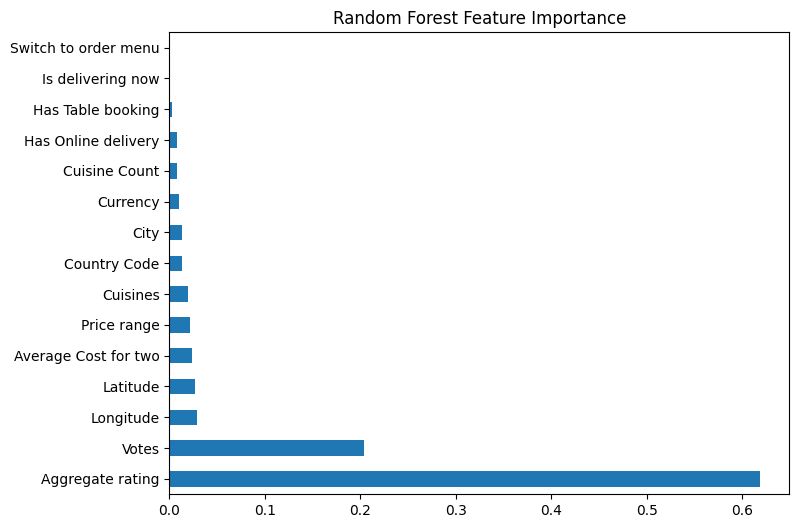

In [40]:
#Feature Importance
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

importance.sort_values(ascending=False).head(15).plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Random Forest Feature Importance")

plt.show()

In [41]:
#comparision table
results = pd.DataFrame({
    "Model":["Random Forest","LightGBM","CatBoost"],
    "Accuracy":[
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, lgb_pred),
        accuracy_score(y_test, cat_pred)
    ],
    "F1 Score":[
        f1_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, lgb_pred, average="weighted"),
        f1_score(y_test, cat_pred, average="weighted")
    ]
})

results


,Model,Accuracy,F1 Score
0,Random Forest,0.996337,0.996297
1,LightGBM,1.000000,1.000000
2,CatBoost,1.000000,1.000000


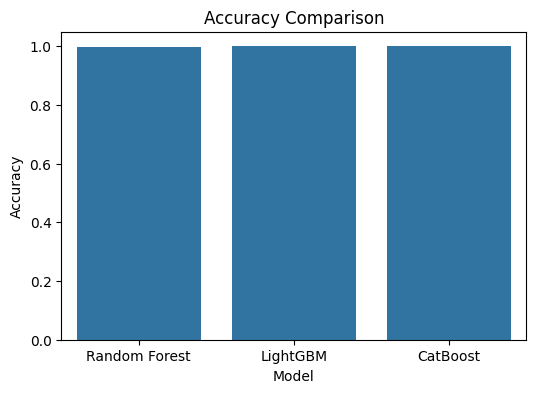

In [42]:
# accuracy graph
plt.figure(figsize=(6,4))

sns.barplot(x="Model", y="Accuracy", data=results)

plt.title("Accuracy Comparison")
plt.show()

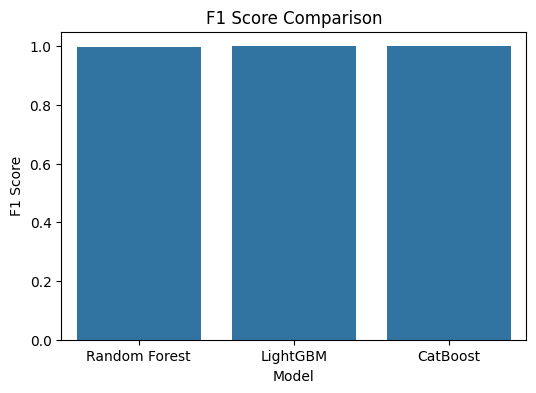

In [43]:
# F1 Score Graph
plt.figure(figsize=(6,4))

sns.barplot(x="Model", y="F1 Score", data=results)

plt.title("F1 Score Comparison")
plt.show()


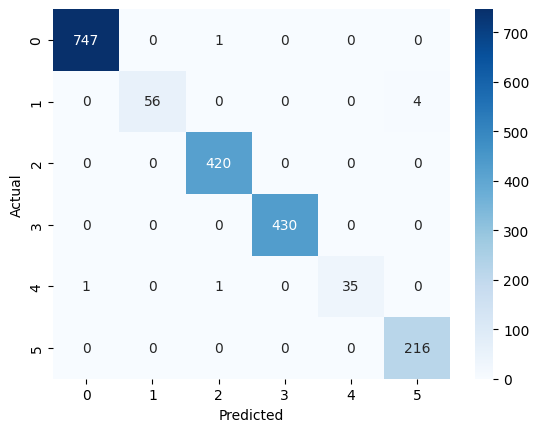

In [44]:
# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [45]:
#Classification Report
print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       748
           1       1.00      0.93      0.97        60
           2       1.00      1.00      1.00       420
           3       1.00      1.00      1.00       430
           4       1.00      0.95      0.97        37
           5       0.98      1.00      0.99       216

    accuracy                           1.00      1911
   macro avg       1.00      0.98      0.99      1911
weighted avg       1.00      1.00      1.00      1911



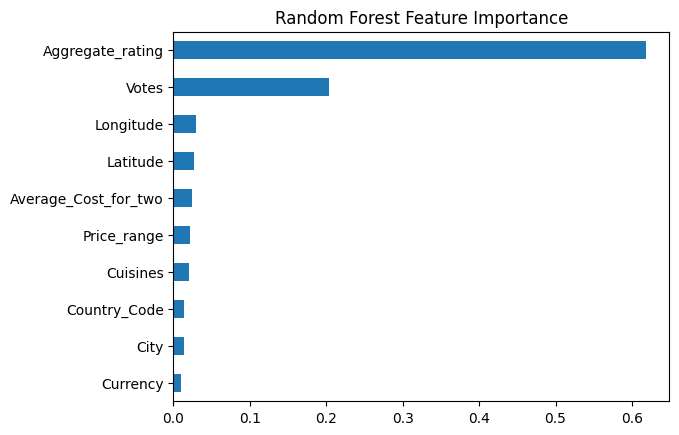

In [46]:
# Feature Importance
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().tail(10).plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.show()

In [47]:
import joblib

joblib.dump(cat, "rating_classifier.pkl")

['rating_classifier.pkl']